M. Amintoosi

edited by : Taraneh Kordi

PyTorch Version

In [10]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import scipy

# Data loading and preprocessing
class PersianDigitsDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data.astype(float)  # Ensure data is float type
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        image = self.data[idx]
        label = int(self.labels[idx]) #- 1  # Assuming labels are 1-based
        
        if self.transform:
            image = self.transform(image)
            
        return image, label


img_rows, img_cols = 26, 26
inputImSize = 26
num_classes = 10
# Load HODA dataset
data_dir = 'data/'
hoda_path = os.path.join(data_dir, 'Data_hoda_full.mat')
hoda = scipy.io.loadmat(hoda_path)

data = hoda['Data'].reshape(-1)
data_resized = np.array([cv2.resize(img, dsize=(inputImSize, inputImSize)) for img in data])
data = np.expand_dims(data_resized, axis=3)
labels = hoda['labels'].reshape(-1)

# Split dataset
train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, random_state=1, test_size=0.1)

# Data augmentation and normalization
transform_train = transforms.Compose([
    lambda x: torch.tensor(x / 255.0),  # Normalize to [0, 1]
    lambda x: x.permute(2, 0, 1).float(),  # Convert to CxHxW format
    transforms.Resize((26, 26)),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform_test = transforms.Compose([
    lambda x: torch.tensor(x / 255.0),
    lambda x: x.permute(2, 0, 1).float(),
    transforms.Resize((26, 26)),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Create datasets
train_dataset = PersianDigitsDataset(train_data, train_labels, transform_train)
test_dataset = PersianDigitsDataset(test_data, test_labels, transform_test)

# Data loaders
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model definition
class SeqModelHoda(nn.Module):
    def __init__(self, input_size=26):
        super(SeqModelHoda, self).__init__()
        
        # Convolutional layers with NO padding (matching TensorFlow default)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=0)  # in_ch=1 → out_ch=32
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0)  # in_ch=32 → out_ch=64
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=0)  # in_ch=64 → out_ch=128

        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Flatten layer
        self.flatten = nn.Flatten()

        # Output layer: input size after pooling → 1×1 × 128 → final vector length = 128
        self.dense1 = nn.Linear(128, 10)  # ✅ Correct input size

    def forward(self, x):
        # Step-by-step with no padding:
        
        # Input: (batch_size, 1, 26, 26)
        x = self.pool1(torch.relu(self.conv1(x)))   # After conv1 → (24×24), pool to (12×12)
        x = self.pool2(torch.relu(self.conv2(x)))   # After conv2 → (10×10), pool to (5×5)
        x = self.pool3(torch.relu(self.conv3(x)))   # After conv3 → (3×3), pool to (1×1)

        x = self.flatten(x)                        # Now: [batch, 128]
        x = torch.softmax(self.dense1(x), dim=1)  # Output: [batch, 10]
        return x

In [11]:
# Initialize model and training parameters
model = SeqModelHoda()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 3
train_loss_history = []
val_loss_history = []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_loss_history.append(epoch_loss)
    
    # Validation
    model.eval()
    val_running_loss = 0.0
    correct = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
    
    val_epoch_loss = val_running_loss / len(val_loader.dataset)
    val_loss_history.append(val_epoch_loss)
    val_accuracy = correct / len(val_loader.dataset)
    
    print(f'Epoch [{epoch + 1}/{num_epochs}]')
    print(f'Train Loss: {epoch_loss:.4f} | Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_accuracy * 100:.2f}%')
    
    # Save best model
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), 'models/best_model-CNN.pth')

Epoch [1/3]
Train Loss: 1.8110 | Val Loss: 1.5422 | Val Acc: 93.08%
Epoch [2/3]
Train Loss: 1.5814 | Val Loss: 1.5123 | Val Acc: 95.48%
Epoch [3/3]
Train Loss: 1.5477 | Val Loss: 1.5004 | Val Acc: 96.57%


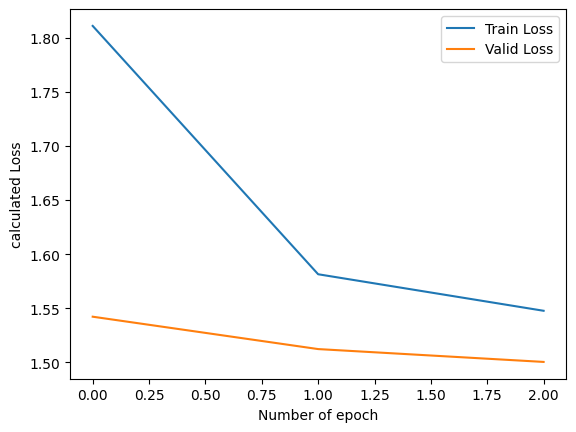

In [12]:
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Valid Loss')
plt.ylabel('calculated Loss')
plt.xlabel('Number of epoch')
plt.legend(loc="upper right")
plt.show()

In [13]:
from torchinfo import summary

input_size = 26
model = SeqModelHoda(input_size)

if  torch.cuda.is_available():
    model.load_state_dict(torch.load('models/best_model-CNN.pth'))
else:
    model.load_state_dict(torch.load('models/best_model-CNN.pth',map_location=torch.device('cpu')))


batch_size = 4
dummy_input = torch.randn(batch_size, 1, input_size, input_size)

# Make a prediction
# output = model(dummy_input)
# print("Output shape:", output.shape)  # Expected: [batch_size, num_classes]

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

input_shape = (1, 1, input_size, input_size)  # Example input shape
summary(model, input_shape)


Total parameters: 93962
Trainable parameters: 93962


Layer (type:depth-idx)                   Output Shape              Param #
SeqModelHoda                             [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 24, 24]           320
├─MaxPool2d: 1-2                         [1, 32, 12, 12]           --
├─Conv2d: 1-3                            [1, 64, 10, 10]           18,496
├─MaxPool2d: 1-4                         [1, 64, 5, 5]             --
├─Conv2d: 1-5                            [1, 128, 3, 3]            73,856
├─MaxPool2d: 1-6                         [1, 128, 1, 1]            --
├─Flatten: 1-7                           [1, 128]                  --
├─Linear: 1-8                            [1, 10]                   1,290
Total params: 93,962
Trainable params: 93,962
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.70
Input size (MB): 0.00
Forward/backward pass size (MB): 0.21
Params size (MB): 0.38
Estimated Total Size (MB): 0.59

In [14]:
import torch
import torch.nn as nn

class FCNModelHoda(nn.Module):
    """convert model SeqModelHoda to Fully Convolutional"""
    def __init__(self, trained_model):
        super(FCNModelHoda, self).__init__()
        
        self.conv1 = trained_model.conv1
        self.pool1 = trained_model.pool1
        self.conv2 = trained_model.conv2
        self.pool2 = trained_model.pool2
        self.conv3 = trained_model.conv3
        self.pool3 = trained_model.pool3
        
        dense_weight = trained_model.dense1.weight  # (10, 128)
        dense_bias = trained_model.dense1.bias      # (10,)
        
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 26, 26)
            x = self.pool1(torch.relu(self.conv1(dummy)))
            x = self.pool2(torch.relu(self.conv2(x)))
            x = self.pool3(torch.relu(self.conv3(x)))
            _, C, H, W = x.shape
        
        self.lastConv = nn.Conv2d(C, 10, kernel_size=(H, W), bias=True)
        
        with torch.no_grad():
            # reshape: (10, 128) -> (10, C, H, W)
            self.lastConv.weight.data = dense_weight.view(10, C, H, W)
            self.lastConv.bias.data = dense_bias
    
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)
        x = torch.relu(self.conv2(x))
        x = self.pool2(x)
        x = torch.relu(self.conv3(x))
        x = self.pool3(x)
        x = self.lastConv(x)  # output : (B, 10, H', W')
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trained_model = SeqModelHoda()
trained_model.load_state_dict(torch.load('models/best_model-CNN.pth', map_location=device))
trained_model.eval()

fcn_model = FCNModelHoda(trained_model).to(device)
fcn_model.eval()

print(fcn_model)


FCNModelHoda(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lastConv): Conv2d(128, 10, kernel_size=(1, 1), stride=(1, 1))
)


In [15]:
from PIL import Image
import torchvision.transforms as transforms
import numpy as np

fileName = 'data/Riazi_Haftom.jpg'

img = Image.open(fileName).convert('L')
img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)


In [16]:
yHat = fcn_model(img_tensor)
yHat = torch.softmax(yHat, dim=1)
yHat.shape  # (1, 10, 15, 111)


torch.Size([1, 10, 15, 111])

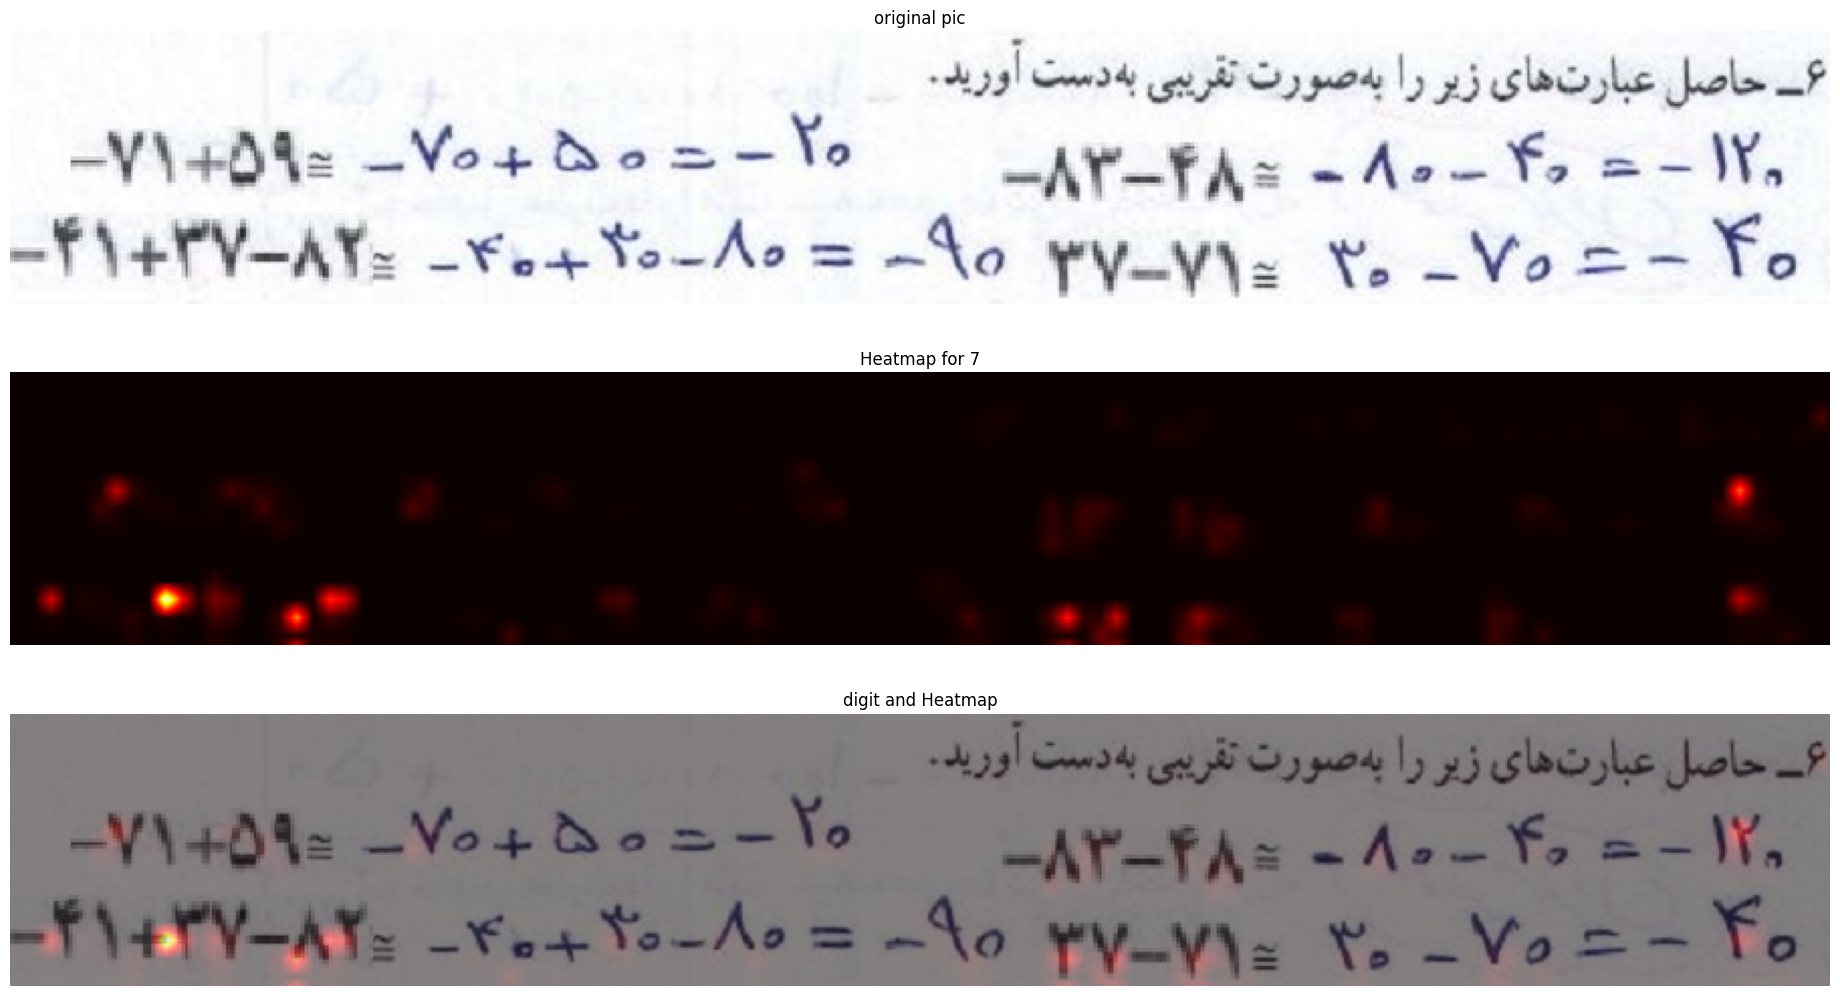

In [19]:
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

digit = 7

heatmap = yHat[0, digit, :, :].cpu().detach().numpy()  # (H', W')

img_rgb = Image.open(fileName).convert('RGB')
img_array = np.array(img_rgb)

from skimage.transform import resize
heatmap_resized = resize(heatmap, (img_array.shape[0], img_array.shape[1]))

fig, ax = plt.subplots(3, 1)
fig.set_size_inches(18.5, 10.5)

ax[0].imshow(img_rgb)
ax[0].axis('off')
ax[0].set_title('original pic')

ax[1].imshow(heatmap_resized, cmap='hot')
ax[1].axis('off')
ax[1].set_title(f'Heatmap for {digit}')

ax[2].imshow(img_rgb)
ax[2].imshow(heatmap_resized, alpha=0.5, cmap='hot')
ax[2].axis('off')
ax[2].set_title('digit and Heatmap')

plt.tight_layout()
plt.show()

fig.savefig('output.jpg', dpi=100, bbox_inches='tight')
